In [1]:
cd ..

/Users/armandoroqueestrada/Desktop/Euskera_data


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import numpy as np
import euskera as eu

import matplotlib.pyplot as plt

In [4]:
address = "Data_122"
format = "npz"
save_number = 200

# Identifying the file names
filenames = eu.nameData(address, format, info=True)
print(filenames)

Found 4 files with the .npz extension.
['end_save_line.npz', 'end_save_plane.npz', 'end_grid.npz', 'end_save_energies.npz']


In [5]:
# extracting the grid coordinates
temp = np.load(address + f"/{filenames[2]}")
grid = [temp[cord] for cord in ['x', 'y', 'z']]

# extracting the conserv. 
temp = np.load(address + f"/{filenames[3]}")
nump_energv = np.array([temp['save_energies%s'%num] for num in range(0, save_number+1)])


# extracting the x-proyection of rho
temp = np.load(address + f"/{filenames[0]}")
lrho = [temp['save_line%s'%num] for num in range(0, save_number+1)]

temp = np.load(address + f"/{filenames[1]}")
planerho = [temp['save_plane%s'%num] for num in range(0, save_number+1)]

Text(0, 0.5, '$\\triangle E_{T}/E_{T}{}_{0}$')

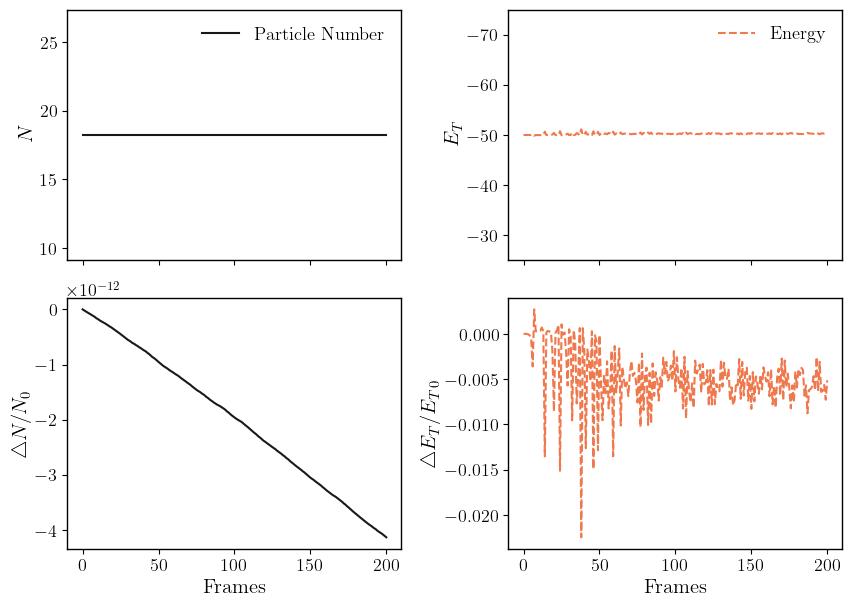

In [6]:

col = ['#1a1919', '#f0784d', '#2681ab', '#ab262f', '#bc92e0', '#486318', '#ed5b0c', 
      '#f0a092', '#484f07', '#694d0c']

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 7),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.15, wspace=.32))


# Particle Number
ax[0][0].plot(nump_energv[:, 0], ls='-', color=col[0], label=r'Particle Number')
temp = nump_energv[0, 0]
ax[1][0].plot((temp-nump_energv[:, 0])/temp, ls='-', color=col[0]) # label=r'N-Euskera'

ax[0][0].set_ylim(nump_energv[0, 0]-nump_energv[0, 0]*0.5, nump_energv[0, 0]+nump_energv[0, 0]*0.5)

# Energy
ax[0][1].plot(nump_energv[:, 1], ls='--', color=col[1], label=r'Energy')
ax[0][1].set_ylim(nump_energv[0, 1]-nump_energv[0, 1]*0.5, nump_energv[0, 1]+nump_energv[0, 1]*0.5)

temp = nump_energv[0, 1]
ax[1][1].plot((temp-nump_energv[:, 1])/temp, ls='--', color=col[1])

for i in range(2):
      ax[1][i].set_xlabel(r"Frames")
      ax[0][i].legend(frameon=False, fontsize='small')
      
##
ax[0][0].set_ylabel(r"$N$")
ax[0][1].set_ylabel(r"$E_{T}$")
##
ax[1][0].set_ylabel(r"$\triangle N/N_{0}$")
ax[1][1].set_ylabel(r"$\triangle E_{T}/E_{T}{}_{0}$")

In [21]:
fig.savefig('rho1D_En_cas01.pdf', format='pdf', pad_inches=0.1, dpi=1000, bbox_inches='tight')

In [7]:
simulation_parameters = {
"lambda_value": 0,  # Self-interaction coupling constant.
"num_threads": 11,  # Set the number of threads to use.
"gridlength": 60,  # Length of the grid in codec units.
"resol": 250,  # Grid resolution. The grid is computed using:
               # linspace(-gridlength/2.0 + gridlength/(2.0*resol), 
               #           gridlength/2.0 - gridlength/(2.0*resol), resol).
"step_factor": 1.,  # Increase this if velocities are low enough that the timestep constraint can be relaxed.
"t0": 0,  # Initial time.
"tmax": 200,  # Total simulation time.
"Plim": 8.6,  # Boundary radius of the soliton.
"rmax": 10.6,  # Two rmax define the minimum separation between solitons 
              # to ensure they are not overlapping.
"cmass": 0,  # Central mass, given in the same units as the soliton mass.
"plott0": False,  # Show the initial profile if True.
"Boverlap": False,  # Check for possible overlap if True.
"methodEnerg": 1,  # methodology used to computed the kinetic contribution
"info": False  # Print extra information if True.
}

# Ground solitond field
# n = 0
En0 = 2.4538867992147075  # energy eingevalue
Mn0 = 5.491059312232425/np.sqrt(2)
fn0 = np.load('./Soliton Profile Files/initial_f_n0.npz')['arr_0']

ind = [lrho[-1] == np.max(lrho[-1])]
val = grid[0][ind[0]][0]

alpha = lambda massC, mass: (massC / mass) ** 2  # Conversion factor
alpha1 = [alpha(Mn0-0.43, Mn0)]

compfield = 1
parameters_sol = {
  "soliton": [{"profiles": [fn0], "positions": [val, 0., 0.], "velocities": [0., 0., 0.], "betas": [En0],
            "phases": [0], "alphas": alpha1, "dr": [0.00001]}]
}

parameters_sol['soliton'][0]['profiles'] = [fn0]

_, rho = eu.solitonProf(compfield, parameters_sol, simulation_parameters)

Text(0.5, 0, 'x')

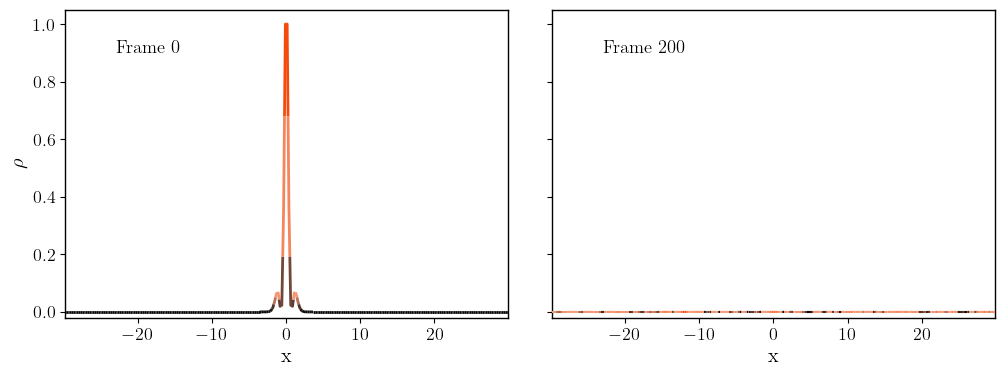

In [14]:
## Plot

col = ['#1a1919', '#f0784d', '#2681ab', '#ab262f', '#bc92e0', '#486318', '#ed5b0c', 
      '#f0a092', '#484f07', '#694d0c']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0.0, wspace=.1))

##########################

frame = 0
x = grid[0]
y = lrho[frame]

vmax = np.abs(y).max()
vmin = np.abs(y).min()


#####
# Convert color list to colormap
cmapint=[(0, '#050505'),
         (0.05, '#f59876'),
         (0.5, '#f57d51'),
         (0.75, '#f76834'),
          (1, '#f54a0c')]

cmap, norm = eu.colorBar_and_normaliz(vmax, vmin, cmapStr=False, cmapint=cmapint)

########################
color = y/vmax
eu.colored_line(x, y/vmax, color, ax[0], linewidth=2, cmap=cmap, zorder=10)

ax[0].text(-23, 0.9, rf"Frame ${frame}$", fontsize='small')
ax[0].set_xlim(x[0], x[-1])
ax[0].set_ylim(-0.02, 1.05)

ax[0].set_ylabel(r"$\rho$")
ax[0].set_xlabel(r"x")


########################
frame = -1
y = lrho[frame]

color2 = y/vmax
eu.colored_line(x, y/vmax, color2, ax[1], linewidth=1.5, cmap=cmap, zorder=10)

ax[1].text(-23, 0.9, rf"Frame ${save_number}$", fontsize='small')

ax[1].set_xlim(x[0], x[-1])
#ax[1].set_ylim(-0.02, 1.05)

#ax[1].set_ylabel(r"$\rho$")
ax[1].set_xlabel(r"x")

################################################
# resol = simulation_parameters["resol"]
# rho_l = rho[:, resol//2, resol//2,]
# rgomax = max(rho_l)

# ax[1].plot(x, rho_l/rgomax, c='r', ls='--', lw=3, label=r'$n=0$')
# ax[1].legend(frameon=False, fontsize='small')

In [9]:
fig.savefig('perfiles.pdf', format='pdf', pad_inches=0.1, dpi=1000, bbox_inches='tight')

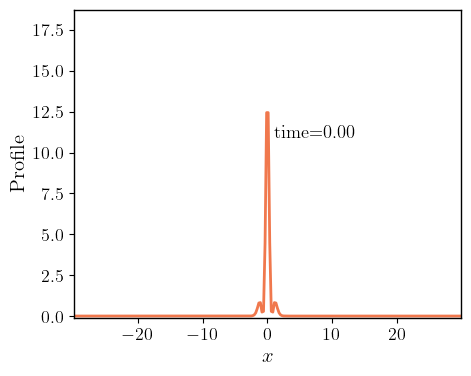

None

In [24]:
#Example of 2D video

Npart = nump_energv[0, 0]
#address = "Data_Est_n0_n0"
figData = plt.subplots(nrows=1, ncols=1, figsize=(5, 4), sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.13))

address = address
dvideo = eu.Visualization(address, figData)  # creando el objeto

n0 = 0  # begin frame
nameP = "save_line"
struc = ['-', 2, '#f0784d']
nameV = 'lin_dens'
coord = ['x']
vconf = [2, 1000000, ['-vcodec', 'libx264']]

video = dvideo.video(nameP, struc, nameV, coord=coord, 
                     xlim=None, ylim=(-0.1, Npart+0.5), vconf=vconf,
                     show=True, n0=n0, plot2D=True, 
                     plot3D=False, save=True, Npart=None)  # in case tha you like to save and not see in the notebook put save to True
display(video)

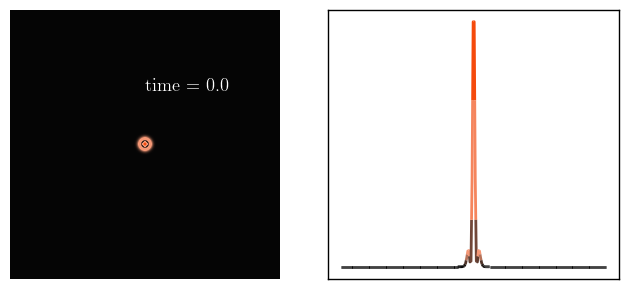

None

In [25]:
# Example of 2D video

#address = "Data_Est_n0_n0"
figData = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.5), sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.13))

dvideo = eu.Visualization(address, figData)  # creando el objeto

n0 = 0  # begin frame
nameP = "save_line"
name2 = "save_plane"
struc = ['-', 2, '#f0784d']
nameV = 'region_dens2'
coord = ['x']
cmapint=[(0, '#050505'),
         (0.05, '#f59876'),
         (0.5, '#f57d51'),
         (0.75, '#f76834'),
          (1, '#f54a0c')]
vconf = [3, 1000000, ['-vcodec', 'libx264']]

text = r''

video = dvideo.video(nameP, struc, nameV, name2=name2, cmapint=cmapint,
                     coord=coord, show=True, n0=n0, plot2D=True, plot3D=False,
                     vconf=vconf, save=True,
                     xlim=(-1, 1), ylim=(-1, 1), text=text)
display(video)